In [1]:
!pip install requests beautifulsoup4 nltk networkx matplotlib


In [2]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\raazi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [1]:
import sys
import os

# Add current project folder to Python path
sys.path.append(os.getcwd())

# Check files in folder (debug)
print("Current Path:", os.getcwd())
print("Files:", os.listdir())


Current Path: C:\Users\raazi\OneDrive\Desktop\privacy-graph-project
Files: ['.conda', '.ipynb_checkpoints', '.virtual_documents', 'anaconda_projects', 'extractor.py', 'graph_builder.py', 'main.py', 'notebook.ipynb', 'requirements.txt', 'scraper.py', '__pycache__']


In [1]:
from scraper import get_policy_text

# Test URL (privacy policy)
url = "https://policies.google.com/privacy"

# Extract policy text
text = get_policy_text(url)

# Print first 500 characters
print(text[:500])


Privacy Policy – Privacy & Terms – Google Privacy & Terms Privacy & Terms Privacy & Terms Overview Privacy Policy Terms of Service Technologies FAQ Google Account Privacy Policy Introduction Information Google collects Why Google collects data Your privacy controls Sharing your information Keeping your information secure Exporting & deleting your information Retaining your information Compliance & cooperation with regulators About this policy Related privacy practices Data transfer frameworks Ke


In [6]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\raazi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\raazi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [2]:
from extractor import split_sentences, simple_extract

# Split into sentences
sentences = split_sentences(text)
print("Total Sentences Extracted:", len(sentences))

# Show first 5 sentences
print("\nSample Sentences:")
print(sentences[:5])

# Extract structured data
data = simple_extract(sentences)

print("\nExtracted Data:")
print(data)


Total Sentences Extracted: 50

Sample Sentences:
['Privacy Policy – Privacy & Terms – Google Privacy & Terms Privacy & Terms Privacy & Terms Overview Privacy Policy Terms of Service Technologies FAQ Google Account Privacy Policy Introduction Information Google collects Why Google collects data Your privacy controls Sharing your information Keeping your information secure Exporting & deleting your information Retaining your information Compliance & cooperation with regulators About this policy Related privacy practices Data transfer frameworks Key terms Partners Updates Google Privacy Policy When you use our services, you’re trusting us with your information.', 'We understand this is a big responsibility and work hard to protect your information and put you in control.', 'This Privacy Policy is meant to help you understand what information we collect, why we collect it, and how you can update, manage, export, and delete your information.', 'Privacy Checkup Looking to change your privacy

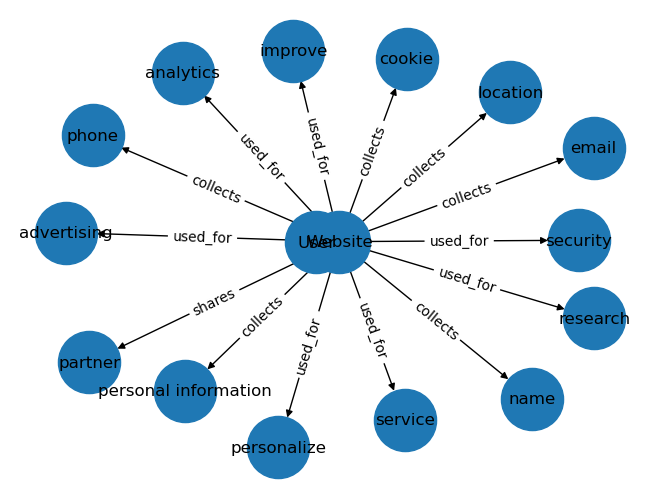

In [3]:
from graph_builder import build_graph, show_graph

# Build graph from extracted data
G = build_graph(data)

# Display the graph
show_graph(G)


In [4]:
print("Sample Sentences Used for Extraction:\n")
for s in sentences[:10]:
    print("-", s)
    
print("\nExtracted Structured Data:\n", data)


Sample Sentences Used for Extraction:

- Privacy Policy – Privacy & Terms – Google Privacy & Terms Privacy & Terms Privacy & Terms Overview Privacy Policy Terms of Service Technologies FAQ Google Account Privacy Policy Introduction Information Google collects Why Google collects data Your privacy controls Sharing your information Keeping your information secure Exporting & deleting your information Retaining your information Compliance & cooperation with regulators About this policy Related privacy practices Data transfer frameworks Key terms Partners Updates Google Privacy Policy When you use our services, you’re trusting us with your information.
- We understand this is a big responsibility and work hard to protect your information and put you in control.
- This Privacy Policy is meant to help you understand what information we collect, why we collect it, and how you can update, manage, export, and delete your information.
- Privacy Checkup Looking to change your privacy settings?
- 

In [4]:
test_urls = [
    "https://policies.google.com/privacy",
    "https://openai.com/policies/privacy-policy/",
    "https://www.microsoft.com/en-us/privacy/privacystatement"
]


for url in test_urls:
    print("\n==============================")
    print("Testing URL:", url)
    
    text = get_policy_text(url)
    sentences = split_sentences(text)
    data = simple_extract(sentences)
    
    print("Extracted Data:", data)



Testing URL: https://policies.google.com/privacy
Extracted Data: {'data_collected': ['email', 'personal information', 'name', 'phone', 'location', 'cookie'], 'shared_with': ['partner', 'analytics'], 'purpose': ['service', 'analytics', 'security', 'advertising', 'research', 'improve', 'personalize']}

Testing URL: https://openai.com/policies/privacy-policy/
Extracted Data: {'data_collected': ['cookie'], 'shared_with': [], 'purpose': []}

Testing URL: https://www.microsoft.com/en-us/privacy/privacystatement
Extracted Data: {'data_collected': ['cookie', 'email', 'location'], 'shared_with': ['affiliates', 'service provider', 'partner'], 'purpose': ['personalize', 'service']}


In [5]:
print("=== Evaluation Summary ===")
print("Total sentences analyzed:", len(sentences))
print("Data types detected:", data["data_collected"])
print("Third parties detected:", data["shared_with"])
print("Purposes detected:", data["purpose"])


=== Evaluation Summary ===
Total sentences analyzed: 50
Data types detected: ['cookie', 'email', 'location']
Third parties detected: ['affiliates', 'service provider', 'partner']
Purposes detected: ['personalize', 'service']
